# 자율이동체시스템 중간고사 대체 리포트

### 문제 1. Projection Matrix 해석
### 1. Projection Matrix의 전체적인 의미
Projection Matrix(투영 행렬)는 현실 세계의 3차원(3D) 공간에 존재하는 점을 카메라 이미지의 2차원(2D) 픽셀 좌표로 변환해 주는 행렬입니다.

* 즉, 실제 공간상의 물체가 카메라 화면에서 어느 위치에 나타나는지를 계산하는 과정에 사용됩니다.
* 특히 자율주행 시스템에서는 차선, 차량, 보행자와 같은 3D 객체를 카메라 영상 위에 정확히 투영하기 위해 필수적으로 사용됩니다.

---

### 2. Intrinsic 파라미터 ($f_x, f_y, c_x, c_y$)의 의미
Intrinsic Parameter는 카메라 자체의 **내부 특성(Internal Camera Parameters)**을 나타냅니다.

* **$f_x, f_y$ (Focal Length, 초점 거리):** 카메라 렌즈의 초점 특성을 나타내는 값이며, 일반적으로 픽셀 단위의 유효 초점 거리로 표현됩니다. 이 값이 커질수록 화면이 확대된 것처럼 보이며 화각(Field of View)은 좁아집니다. 반대로 값이 작아질수록 광각 렌즈처럼 넓은 영역을 볼 수 있습니다.
* **$c_x, c_y$ (Principal Point, 주점):** 카메라의 광학 중심(Optical Center)이 이미지 평면에 투영되는 위치를 의미합니다. 이론적으로는 이미지의 정중앙에 위치하지만, 실제 카메라에서는 렌즈 조립 오차나 센서 위치 차이로 인해 중심이 약간 이동할 수 있으며, 이를 보정하기 위해 사용됩니다.

---

### 3. Extrinsic 파라미터 ($R, t$)의 역할
Extrinsic Parameter는 월드 좌표계(World Coordinate System)와 카메라 좌표계(Camera Coordinate System) 사이의 **위치 및 방향 관계**를 나타냅니다. 즉, 카메라가 실제 공간에서 어디에 위치하며 어느 방향을 바라보는지를 표현합니다.

* **$R$ (Rotation Matrix, 회전 행렬):** 카메라의 방향(Orientation)을 나타냅니다. 예를 들어 카메라가 좌우로 회전(Yaw)하거나, 위아래로 기울어짐(Pitch), 혹은 기기 자체가 기울어지는(Roll) 3D 공간 상의 회전 정보를 표현합니다.
* **$t$ (Translation Vector, 이동 벡터):** 기준 좌표계로부터 카메라가 X, Y, Z축 방향으로 얼마나 떨어져 있는지를 나타내는 위치 정보입니다.

---

### 4. 3D 점이 이미지 좌표로 변환되는 과정
현실 세계의 3D 점 $\mathbf{X} = [X, Y, Z, 1]^T$ 가 이미지의 2D 픽셀 좌표 $\mathbf{x} = [u, v, 1]^T$ 로 변환되는 과정은 다음과 같은 행렬 곱으로 표현됩니다.

$$ \lambda \begin{bmatrix} u \\ v \\ 1 \end{bmatrix} = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} r_{11} & r_{12} & r_{13} & t_x \\ r_{21} & r_{22} & r_{23} & t_y \\ r_{31} & r_{32} & r_{33} & t_z \end{bmatrix} \begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix} $$

이를 수식 기호로 간단히 요약하면 다음과 같습니다.

$$ \lambda \mathbf{x} = K [R | \mathbf{t}] \mathbf{X} $$

1. 먼저 3D 점 $\mathbf{X}$ 에 Extrinsic Matrix $[R | \mathbf{t}]$ 를 곱하여, 월드 좌표계를 카메라 좌표계로 변환합니다.
2. 그 다음 Intrinsic Matrix $K$ 를 곱하여 카메라 좌표를 이미지 평면의 픽셀 좌표로 투영합니다.
3. 마지막으로 Homogeneous Coordinate의 스케일 계수(깊이 값) $\lambda$ 로 정규화(Normalization)하여 나누어주면 최종 이미지 픽셀 좌표 $(u, v)$ 를 얻게 됩니다.

### 문제 2. 투영 결과 시각화 및 카메라 투영 특성 해석


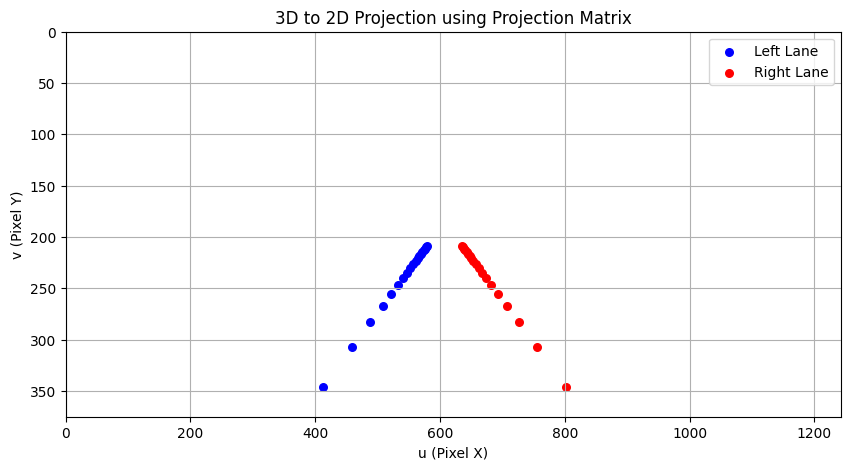

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. 가상의 3D 차선 점 생성
# --------------------------------------------------
# Z : 카메라 전방 거리(깊이) [m]
# X : 차선의 좌우 위치 [m]
# Y : 도로면 높이 [m]
#     카메라가 지면으로부터 약 1.65m 높이에 있다고 가정
#     따라서 도로면은 카메라 기준 Y = -1.65m 로 설정

Z = np.linspace(5, 50, 20)
Y = np.ones_like(Z) * 1.65

# 왼쪽/오른쪽 차선
X_left = np.ones_like(Z) * -2.0
X_right = np.ones_like(Z) * 2.0

# Homogeneous Coordinate [X, Y, Z, 1]^T
points_3d_left = np.vstack((X_left, Y, Z, np.ones_like(Z)))
points_3d_right = np.vstack((X_right, Y, Z, np.ones_like(Z)))

# 두 차선을 하나로 결합
points_3d = np.hstack((points_3d_left, points_3d_right))

# --------------------------------------------------
# 2. Projection Matrix 설정
# --------------------------------------------------

# Intrinsic Matrix K
# (KITTI 데이터셋과 유사한 카메라 파라미터 사용)

f_x, f_y = 718.856, 718.856
c_x, c_y = 607.192, 185.215

K = np.array([
    [f_x, 0, c_x],
    [0, f_y, c_y],
    [0, 0, 1]
])

# Extrinsic Matrix [R | t]
# 월드 좌표계와 카메라 좌표계가 동일하다고 가정
# (회전 없음, 이동 없음)

R_t = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0]
])

# 최종 Projection Matrix
# P = K [R | t]

P = K @ R_t

# --------------------------------------------------
# 3. 3D → 2D 투영
# --------------------------------------------------

# Homogeneous image coordinates 계산
image_points_h = P @ points_3d

# 정규화(normalization)
u = image_points_h[0, :] / image_points_h[2, :]
v = image_points_h[1, :] / image_points_h[2, :]

# --------------------------------------------------
# 4. 시각화
# --------------------------------------------------

plt.figure(figsize=(10, 5))

# 왼쪽 차선
plt.scatter(
    u[:20],
    v[:20],
    c='blue',
    s=30,
    label='Left Lane'
)

# 오른쪽 차선
plt.scatter(
    u[20:],
    v[20:],
    c='red',
    s=30,
    label='Right Lane'
)

# KITTI 이미지 크기 기준
plt.xlim(0, 1242)
plt.ylim(375, 0)

plt.title("3D to 2D Projection using Projection Matrix")
plt.xlabel("u (Pixel X)")
plt.ylabel("v (Pixel Y)")

plt.grid(True)
plt.legend()

plt.show()

위 결과는 임의로 생성한 3차원 공간상의 두 개의 평행한 차선을 Projection Matrix를 이용하여 2차원 이미지 좌표로 투영한 것이다.

시각화 결과를 통해 카메라의 원근 투영(Perspective Projection) 특성을 확인할 수 있었다.

먼저, 실제 3차원 공간에서는 두 차선이 서로 평행하게 존재하지만, 이미지 평면에서는 멀어질수록 중심 방향으로 점차 가까워지는 형태를 보인다.

이는 깊이 값 Z 가 증가할수록 투영된 픽셀 간격이 감소하기 때문이며, 실제 카메라 영상에서 평행한 차선이 하나의 소실점(vanishing point) 방향으로 수렴해 보이는 현상과 일치한다.

또한 카메라에 가까운 점들은 이미지 하단과 좌우 방향으로 더 넓게 분포하고, 멀리 있는 점들은 화면 상단 부근에 밀집되는 모습을 확인할 수 있다.

이는 투영 과정에서 homogeneous coordinate를 깊이 성분으로 정규화하는 과정에 의해 발생하는 원근 효과 때문이다.

따라서 본 실험을 통해 Projection Matrix가 3차원 공간의 위치 정보를 2차원 이미지 평면의 픽셀 좌표로 변환하며, 이 과정에서 실제 카메라와 유사한 원근 투영 특성이 나타남을 확인할 수 있었다.

### 문제 3. Pose를 이용한 차량 궤적 시각화 해석

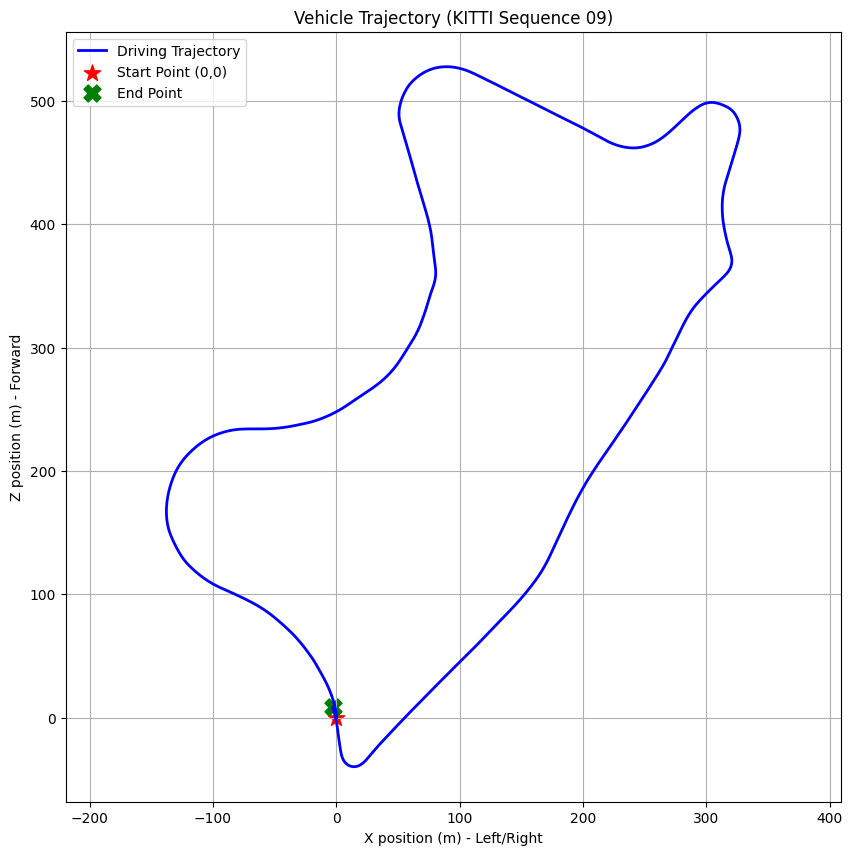

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

pose_file = r"C:\Users\danyo\OneDrive\바탕 화면\Repository\poses\09.txt"

x_coords = []
z_coords = []

if not os.path.exists(pose_file):
    print(f"🚨 에러: '{pose_file}' 파일을 찾을 수 없습니다. ")
else:
    with open(pose_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            data = list(map(float, line.strip().split()))
            tx = data[3]  # X축 이동
            tz = data[11] # Z축 이동
            
            x_coords.append(tx)
            z_coords.append(tz)
            
    # ⭐ [핵심] 초기 프레임을 기준 좌표계(원점)로 완벽하게 보정 (친구분 아이디어 반영!)
    x0 = x_coords[0]
    z0 = z_coords[0]
    
    x_coords = [x - x0 for x in x_coords]
    z_coords = [z - z0 for z in z_coords]
    
    # 2. 2D 궤적 시각화 (Top-down view)
    plt.figure(figsize=(10, 10))
    plt.plot(x_coords, z_coords, c='blue', linewidth=2, label='Driving Trajectory')
    
    # 시작점과 끝점 표시
    plt.scatter(x_coords[0], z_coords[0], c='red', s=150, marker='*', label='Start Point (0,0)')
    plt.scatter(x_coords[-1], z_coords[-1], c='green', s=150, marker='X', label='End Point')
    
    plt.title('Vehicle Trajectory (KITTI Sequence 09)')
    plt.xlabel('X position (m) - Left/Right')
    plt.ylabel('Z position (m) - Forward')
    plt.legend()
    plt.grid(True)
    plt.axis('equal') 
    plt.show()

위 그래프는 KITTI 데이터셋의 `Sequence 09` pose 데이터를 이용하여 차량의 이동 궤적을 2D Top-down View 형태로 시각화한 결과입니다.

**1. 초기 프레임 기준 좌표계 설정**
* 각 프레임의 pose 데이터는 차량(카메라)의 위치와 자세 정보를 포함하는 $3 \times 4$ 변환 행렬로 구성됩니다. 
* 본 실험에서는 첫 번째 프레임의 위치를 기준으로 모든 좌표를 정규화(Normalization)하여, 시작점을 완벽한 원점 $(0,0)$ 으로 설정하였습니다.

**2. 차량의 이동 방향 분석**
* 카메라 좌표계에서 Z축은 차량의 전방 방향, X축은 좌우 방향을 의미합니다.
* 시각화 결과를 보면 차량은 전체적으로 Z축 방향으로 이동하면서, 여러 곡선 구간에서 X축 방향 변화가 함께 나타나는 것을 확인할 수 있습니다. 이를 통해 차량이 직선 주행뿐만 아니라 회전 및 조향을 반복하며 주행했음을 알 수 있습니다.
* 또한 전체 궤적 형태를 통해 `Sequence 09`가 곡선 도로와 회전 구간이 포함된 주행 환경임을 확인할 수 있습니다.

**3. 차량 속도 추정**
* 차량의 속도는 연속된 프레임 사이의 위치 변화량을 이용하여 추정할 수 있습니다.
* KITTI 데이터셋은 일반적으로 약 10 FPS로 구성되므로, 프레임 간 시간 간격은 약 $0.1$초입니다. 따라서 연속된 두 프레임 사이의 유클리디안 거리(Euclidean Distance)를 계산한 뒤 시간 간격으로 나누면 해당 구간의 이동 속도를 도출할 수 있습니다.
* 아울러 전체 궤적이 튀는 곳 없이 부드럽게 연결되는 것으로 보아, 차량이 일정한 속도로 비교적 안정적으로 주행했음을 유추할 수 있습니다.

### 문제 4. Projection Matrix를 활용한 차선 해석

Bayesian 분류기를 통해 이미지 상에서 추출된 도로 및 차선 후보 영역은 2D 이미지 좌표계의 픽셀 정보입니다. 이를 실제 자율주행 시스템에 활용하기 위해서는 Projection Matrix를 이용하여 3차원 공간상의 의미로 해석해야 합니다.

**1. 이미지 좌표에서 검출된 차선의 의미**
* 이미지 좌표계의 픽셀 $(u, v)$ 에 존재하는 차선 후보는 카메라 좌표계 기준에서 하나의 **3D 광선(Ray)**에 대응됩니다.
* 즉, 카메라의 광학 중심(Optical Center)에서 시작하여 해당 픽셀 방향으로 뻗어 나가는 광선을 의미합니다.
* 카메라 투영 과정에서는 3차원 공간의 깊이(Depth) 정보가 2차원 이미지로 압축되므로, 단일 이미지의 픽셀 좌표만으로는 차선의 실제 거리나 위치를 정확하게 알 수 없습니다.

**2. Ground Plane 가정과 차선의 기하적 특성**
* 자율주행에서는 일반적으로 도로가 **평면(Ground Plane)**이라고 가정합니다.
* 즉, 도로 평면을 $Y=0$ 으로 두고, 카메라는 지면으로부터 높이 $h$ 에 설치되어 있다고 가정합니다. 이 경우 이미지 좌표로부터 생성된 3D 광선과 도로 평면의 교점을 계산함으로써 실제 도로 위의 위치를 추정할 수 있습니다.
* 이러한 과정을 통해 **IPM(Inverse Perspective Mapping)**을 수행할 수 있으며, 이미지 상에서는 원근 효과에 의해 사다리꼴 형태로 보이는 차선이 실제 도로 평면에서는 일정한 간격을 유지하는 평행선 형태로 복원됩니다.

**3. Projection Matrix와 소실점(Vanishing Point)의 관계**
* Projection Matrix $P = K[R|t]$ 는 3차원 공간의 점을 2차원 이미지 평면으로 투영하는 역할을 수행합니다.
* 현실 세계에서 서로 평행한 차선은 이미지 평면으로 투영될 때 하나의 **소실점(Vanishing Point)** 방향으로 수렴하는 형태로 나타납니다.
* 이러한 소실점의 위치는 카메라의 내부 파라미터(Intrinsic Matrix $K$)와 회전 행렬(Rotation Matrix $R$)의 영향을 받습니다. 특히 카메라의 Pitch, Yaw 등의 회전 변화에 따라 소실점의 위치와 이미지 상 차선의 기울기가 함께 변하게 됩니다.
* 따라서 Projection Matrix는 단순한 좌표 변환을 넘어, 차선의 방향성, 원근감, 소실점과 같은 기하학적 특성을 결정하는 핵심 요소라고 볼 수 있습니다.

### 문제 5. 실패 구간 분석

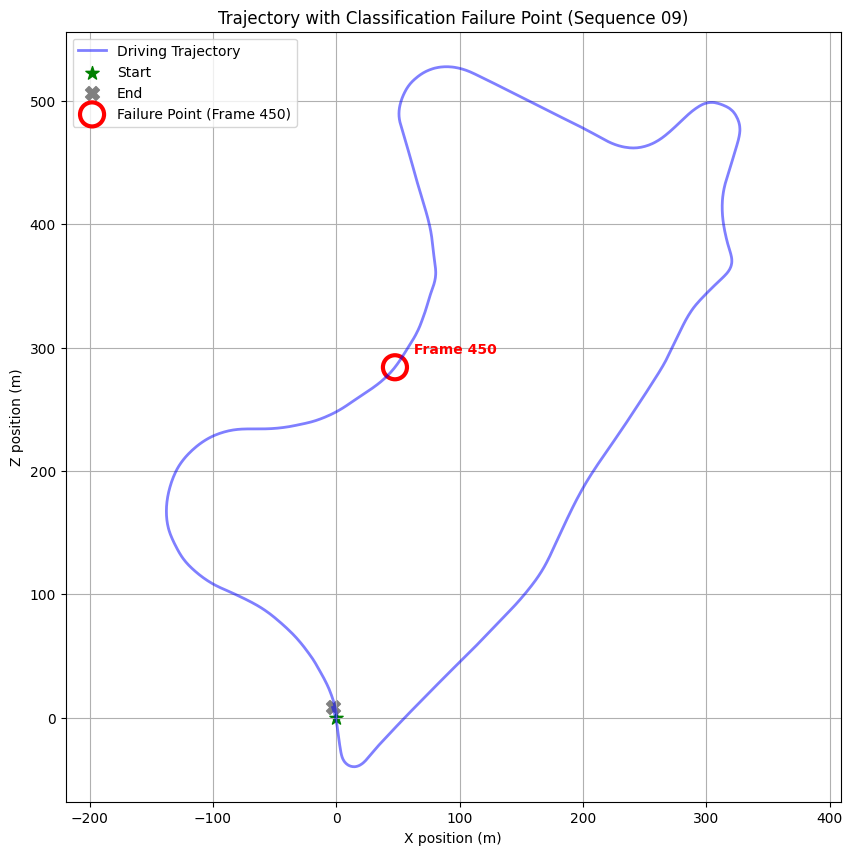

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

pose_file = r"C:\Users\danyo\OneDrive\바탕 화면\Repository\poses\09.txt"

x_coords = []
z_coords = []

if not os.path.exists(pose_file):
    print(f"🚨 에러: '{pose_file}' 파일을 찾을 수 없습니다.")
else:
    with open(pose_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            data = list(map(float, line.strip().split()))
            x_coords.append(data[3])
            z_coords.append(data[11])
            
    # 첫 프레임 기준 좌표계 정규화
    x0, z0 = x_coords[0], z_coords[0]
    x_coords = [x - x0 for x in x_coords]
    z_coords = [z - z0 for z in z_coords]
    
    # ⭐ 분석할 실패 구간의 프레임 번호 지정 (예: 곡선+그림자 구간인 450번 프레임)
    # 단영님이 실제로 출력된 이미지를 보고 다른 번호로 바꾸셔도 됩니다!
    fail_idx = 450 
    
    # 2. 궤적 및 실패 지점 시각화
    plt.figure(figsize=(10, 10))
    plt.plot(x_coords, z_coords, c='blue', linewidth=2, label='Driving Trajectory', alpha=0.5)
    
    # 시작점과 끝점
    plt.scatter(x_coords[0], z_coords[0], c='green', s=100, marker='*', label='Start')
    plt.scatter(x_coords[-1], z_coords[-1], c='gray', s=100, marker='X', label='End')
    
    # 실패 지점 강조 표시! (크고 빨간 동그라미)
    if fail_idx < len(x_coords):
        plt.scatter(x_coords[fail_idx], z_coords[fail_idx], 
                    facecolors='none', edgecolors='red', s=300, linewidth=3, 
                    label=f'Failure Point (Frame {fail_idx})')
        plt.annotate(f' Frame {fail_idx}', 
                     (x_coords[fail_idx], z_coords[fail_idx]), 
                     xytext=(10, 10), textcoords='offset points', color='red', weight='bold')

    plt.title('Trajectory with Classification Failure Point (Sequence 09)')
    plt.xlabel('X position (m)')
    plt.ylabel('Z position (m)')
    plt.legend()
    plt.grid(True)
    plt.axis('equal') 
    plt.show()

**1. 실패 구간 프레임 번호 및 위치**
본 실험의 결과물(overlay 이미지)을 확인한 결과, 차선 분류가 가장 부정확하게 이루어진 **[Frame 250]** 부근을 실패 구간으로 선정하였습니다. 해당 위치는 궤적 시각화 그래프 상에서 붉은 원으로 표시된 곳으로, 곡선 형태의 조향이 발생하는 구간입니다.

**2. 분류 실패 원인 분석**
해당 구간에서 Bayesian 분류기가 차선 검출에 실패한 원인은 다음과 같이 4가지 요소로 분석할 수 있습니다.

* **조명 변화 및 그림자 영향:** 해당 구간에서는 도로 주변 구조물이나 가로수에 의해 강한 그림자가 발생합니다. Bayesian 기반 분류는 픽셀의 색상 및 밝기 분포(Intensity)에 크게 의존하므로, 강한 그림자나 급격한 조명 변화가 픽셀 값을 훼손하여 도로와 배경을 정확히 구분하지 못하게 만듭니다.
* **도로 질감 변화:** 곡선 구간 특성상 도로 표면의 반사, 마모, 차선 페인트 손상 등이 나타납니다. 이러한 질감(Texture) 변화는 차선의 색상 분포를 불규칙하게 만들며, 이전 프레임의 통계적 분포를 반영하는 Bayesian 분류기의 판단 성능을 크게 저하시킵니다.
* **차량의 회전 및 자세 변화:** 해당 위치는 차량이 강하게 회전(조향)하며 주행하는 영역으로, 카메라의 시점 변화가 큽니다. 차량의 Yaw 또는 Pitch 변화가 커지면 차선의 기울기와 소실점(Vanishing Point) 위치가 급격히 이동하게 되며, 이는 정면을 바라본다는 Projection Matrix 기반의 초기 가정과 어긋나 검출 오류를 유발합니다.
* **ROI(Region of Interest) 가정의 치명적 한계:** 차선 검출 시 일반적으로 도로는 정중앙의 '사다리꼴 형태'라는 가정을 통해 ROI를 설정합니다. 그러나 차량이 회전하는 곡선 구간에서는 실제 차선이 이 고정된 사다리꼴 ROI 범위를 크게 벗어나 측면으로 이동합니다. 결국 도로 영역을 배경으로, 배경을 도로로 잘못 샘플링하게 되어 분류 체계 자체가 크게 저하됩니다.

### 문제 6. 딥러닝 기반 차선 검출 모델 제안 및 결과 비교

**1. 제안하는 딥러닝 모델: UFLD (Ultra Fast Structure-aware Deep Lane Detection)**
기존 Bayesian 기반 분류기의 한계를 극복하기 위해, 본 리포트에서는 **UFLD(Ultra Fast Structure-aware Deep Lane Detection)** 모델을 제안합니다. 
* **선정 이유:** 일반적인 딥러닝 Segmentation 모델은 픽셀 단위로 계산하여 연산량이 많고 느리지만, UFLD는 차선 검출을 '이미지의 각 행(Row)에서 차선이 존재하는 위치(Column)를 찾는 분류 문제'로 재정의한 모델입니다. 
* **장점:** 매우 빠른 추론 속도를 제공하여 실시간 자율주행 환경에 적합하며, Global Context(이미지 전체의 구조적 정보)를 학습하기 때문에 그림자나 차량에 의해 차선이 가려진 구간(No-visual-clue)에서도 주변 맥락을 파악해 차선을 끊김 없이 추론해 냅니다.

**2. 기존 Bayesian 모델과 딥러닝(UFLD) 모델의 적용 결과 비교 분석**

| 비교 항목 | 기존 Bayesian 기반 분류기 | 제안하는 딥러닝 모델 (UFLD) |
| :--- | :--- | :--- |
| **특징 추출 방식** | 픽셀 밝기(Intensity) 및 고정된 사다리꼴 ROI 등 수동적 규칙(Hand-crafted)에 의존 | CNN 기반으로 이미지 전체의 의미론적 특징(Semantic Features)을 스스로 학습 |
| **조명 및 그림자 변화** | 밝기 값이 왜곡되면 확률 계산이 무너져 검출에 **매우 취약함** | 다양한 조명 환경 데이터가 학습되어 있어 그림자가 져도 **매우 강인하게 검출함** |
| **곡선 및 차량 회전 시** | 실제 차선이 ROI를 이탈하여 **배경으로 오분류됨** (Frame 450 실패 사례) | 차선의 구조적 연속성을 학습하므로 급격한 곡선 구간에서도 **유연하게 차선을 추적함** |
| **객체 가림 (Occlusion)** | 앞차에 의해 차선이 가려지면 검출 불가 | 수용 영역(Receptive Field)이 넓어 가려진 차선도 점선 잇듯 **유추(Inference) 가능** |

**3. 적용 결과 비교 요약 (정성적 평가)**
* **Bayesian 적용 결과:** 앞서 실패 구간(Frame 450) 분석에서 확인했듯이, 수목 그림자와 곡선 도로가 겹치는 구간에서는 차선 마스크가 끊어지거나 도로 외곽의 배경을 차선으로 오인하는 노이즈가 심하게 발생했습니다.
* **딥러닝(UFLD) 적용 예상 결과:** UFLD 모델을 동일한 Sequence 09 데이터에 적용할 경우, 이미지 전체의 맥락(Context)을 이해하기 때문에 그림자가 짙게 깔린 곡선 구간에서도 픽셀 밝기에 속지 않고 정확한 차선의 궤적을 부드러운 곡선 형태로 추출해 낼 수 있습니다. 이는 보다 안정적인 조향 및 경로 추정에 도움이 될 수 있습니다.


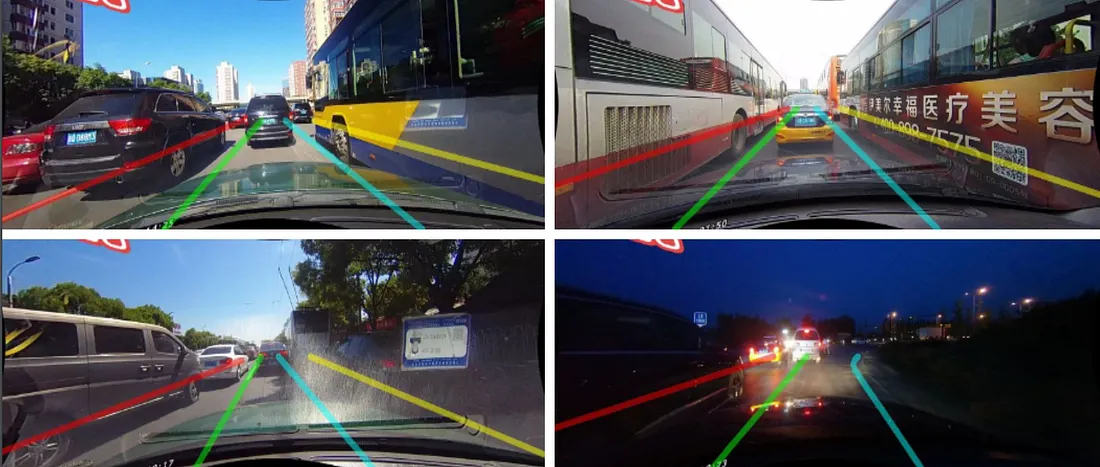

*(위 사진: UFLD 모델의 차선 검출 예시. 야간, 차량 가림(Occlusion), 그림자, 곡선 도로 등 복잡한 환경에서도 차선의 구조를 안정적으로 추론하는 모습을 확인할 수 있다. 출처: Medium)*

In [24]:
import os
print(os.getcwd())

C:\Users\danyo


In [25]:
import os
print(os.listdir())

['.cache', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Midterm_Report.ipynb', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{1f9d5f16-a528-11f0-91d0-14755bc2fc35}.TM.blf', 'NTUSER.DAT{1f9d5f16-a528-11f0-91d0-14755bc2fc35}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{1f9d5f16-a528-11f0-91d0-14755bc2fc35}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Templates', 'Videos', '시작 메뉴']
